## ⚠️ IMPORTANT: Before Running

### Required folder structure in Google Drive:
```
MyDrive/images/
  ├── cassiopeia/
  ├── crux/
  ├── cygnus/
  ├── gemini/
  ├── leo/
  ├── orion/
  └── ursa_major/
```
Access images here: [Constellation Images](https://drive.google.com/drive/folders/1q4SkFq9ItMgH9Xq33CHmbNABI9_7iljr?usp=sharing)

### What changed from the original notebook (conference version):
1. **3-way split** — train / validation / test (70% / 15% / 15%). Test set held out completely until final evaluation.
2. **Reproducible shuffles** — every shuffle uses a fixed `RANDOM_SEED`.
3. **Augmentation-after-split guaranteed** — augmentation only applied to the training directory.
4. **5-fold stratified cross-validation** — stable mean ± std accuracy across folds.
5. **Multiple seed runs** — best architecture retrained 5× with different seeds.
6. **Baseline model** — simple 3-layer CNN evaluated alongside MobileNetV2.
7. **Linear pipeline** — two-phase fine-tuning now correctly placed BEFORE multi-seed evaluation. 'Run All' is unambiguous.
8. **Single held-out test evaluation** — test set touched exactly once (final starred cell). All intermediate duplicate evaluations removed.
9. **Correct 95% CI** — uses t-distribution (df=N_SEEDS−1) instead of invalid normal approximation for n=5.
10. **Perceptual hash de-duplication** — near-duplicates (same image, different crop/watermark) caught via `imagehash`, not just MD5.
11. **Post-split stratification check** — assertion verifies class balance is preserved across all three splits.
12. **Dataset provenance summary** — cell records source counts, licenses, and data-cleaning decisions.
13. **Mislabeled cell fixed** — 'Validation Set Confusion Matrix' cell renamed to correctly say 'Test Set'.


## Imports and Environment Setup

In [ ]:
import os
import shutil
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image as PILImage
from IPython.display import display
from google.colab import drive

drive.mount('/content/drive')
print(f"TensorFlow Version: {tf.__version__}")

Mounted at /content/drive
TensorFlow Version: 2.19.0


## Project Configuration

In [ ]:
# ── Directory paths ──────────────────────────────────────────
DATA_DIR   = '/content/drive/MyDrive/images'
TRAIN_DIR  = '/content/train'
VAL_DIR    = '/content/validation'
TEST_DIR   = '/content/test'          # NEW: held-out test set
MODEL_DIR  = '/content/drive/MyDrive/models'

# ── Hyperparameters ───────────────────────────────────────────
IMG_HEIGHT    = 224
IMG_WIDTH     = 224
BATCH_SIZE    = 8
EPOCHS        = 50
LEARNING_RATE = 0.001

# ── Split ratios (must sum to 1.0) ────────────────────────────
TRAIN_SPLIT = 0.70   # 70% training
VAL_SPLIT   = 0.15   # 15% validation
TEST_SPLIT  = 0.15   # 15% held-out test  ← NEW

# ── Reproducibility ───────────────────────────────────────────
RANDOM_SEED = 42     # fixes all shuffles for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Cross-validation / multi-seed settings ────────────────────
N_FOLDS     = 5      # 5-fold stratified CV
N_SEEDS     = 5      # number of different seeds for final variance estimate

os.makedirs(MODEL_DIR, exist_ok=True)
print("Configuration initialized.")
print(f"  Split  →  train {TRAIN_SPLIT:.0%} | val {VAL_SPLIT:.0%} | test {TEST_SPLIT:.0%}")
print(f"  Seed   →  {RANDOM_SEED}")
print(f"  CV folds: {N_FOLDS}  |  Multi-seed runs: {N_SEEDS}")


Configuration initialized.
  Split  →  train 70% | val 15% | test 15%
  Seed   →  42
  CV folds: 5  |  Multi-seed runs: 5


## Utility Functions — Image Preprocessing

1. The "Background Color" ProblemCurrently, you composite transparent images (PNGs/WebPs) onto a white background (255, 255, 255).The Issue: Astronomical images are almost exclusively dark/black. If you take a transparent diagram of a constellation and put it on a white background, you are creating a "negative" image that is statistically opposite to your real-world photographs. This will confuse the model.The Fix: Change the composite background to black (0, 0, 0).

2. Integrity & De-duplication (Leakage Control)The professor warned about "near-duplicate images." Even if filenames are different, the binary data might be the same.The Fix: Add a simple MD5 hashing check. This ensures that if you accidentally downloaded the same image twice (one as a .png and one as a .webp), you catch it now before it leaks into both your training and test sets.

3. Resolution ValidationTo ensure "Dataset validity," you should filter out images that are too small. Feeding a $20 \times 20$ pixel thumbnail into MobileNetV2 (which expects $224 \times 224$) will result in heavy blurring/artifacts.

In [ ]:
# Install imagehash for perceptual near-duplicate detection
# MD5 only catches exact byte-level duplicates. imagehash catches the same image
# with different crops, watermarks, or JPEG re-compression — common in web scrapes.
import subprocess
subprocess.run(['pip', 'install', 'imagehash', '-q'], check=True)

import hashlib
import imagehash

def convert_all_images_to_jpg(data_dir, min_size=(100, 100), phash_threshold=8):
    """
    Standardizes the dataset:
      1. Discards images below min_size (resolution validation).
      2. Removes near-duplicates via perceptual hashing (imagehash.phash).
         Hamming distance <= phash_threshold is treated as a near-duplicate.
      3. Composites transparent pixels onto a BLACK background (star fields
         are dark — white compositing creates inverted/negative artefacts).
      4. Converts all images to JPEG at quality=95 for format consistency.

    Args:
        data_dir        : Root directory with one sub-folder per class.
        min_size        : (width, height) minimum acceptable resolution.
        phash_threshold : Hamming distance threshold; 8 is a standard
                          conservative value (lower = stricter).
    """
    if not os.path.exists(data_dir):
        print(f"Error: Directory not found at {data_dir}")
        return

    total_converted      = 0
    total_deleted_small  = 0
    total_deleted_dupes  = 0
    seen_phashes         = []   # list of imagehash objects for Hamming comparison

    folders = sorted([f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))])
    print("Initiating rigorous image standardization (perceptual hashing)...")

    for folder in folders:
        folder_path = os.path.join(data_dir, folder)
        files       = sorted(os.listdir(folder_path))
        print(f"  Processing class: {folder} ({len(files)} files)")

        for img_file in files:
            file_path = os.path.join(folder_path, img_file)
            try:
                with PILImage.open(file_path) as img:

                    # 1. Resolution Validation
                    if img.size[0] < min_size[0] or img.size[1] < min_size[1]:
                        print(f"    Discarding {img_file}: resolution too low ({img.size})")
                        os.remove(file_path)
                        total_deleted_small += 1
                        continue

                    # 2. Near-Duplicate Detection via Perceptual Hash
                    ph = imagehash.phash(img)
                    if any(abs(ph - seen) <= phash_threshold for seen in seen_phashes):
                        print(f"    Deleting near-duplicate: {img_file}")
                        os.remove(file_path)
                        total_deleted_dupes += 1
                        continue
                    seen_phashes.append(ph)

                    # 3. Transparency Handling — BLACK background for astronomical images
                    if img.mode in ('RGBA', 'LA', 'P'):
                        background = PILImage.new('RGB', img.size, (0, 0, 0))  # BLACK
                        if img.mode == 'P':
                            img = img.convert('RGBA')
                        background.paste(img,
                                         mask=img.split()[-1] if img.mode == 'RGBA' else None)
                        img = background
                    elif img.mode != 'RGB':
                        img = img.convert('RGB')

                    # 4. Standardize to JPEG
                    jpg_path = os.path.join(folder_path,
                                            os.path.splitext(img_file)[0] + '.jpg')
                    img.save(jpg_path, 'JPEG', quality=95)
                    if not img_file.lower().endswith('.jpg'):
                        os.remove(file_path)
                        total_converted += 1

            except Exception as e:
                print(f"    Failed to process {img_file}: {e}")

    print(f"\n✓ Standardization complete.")
    print(f"  Converted         : {total_converted}")
    print(f"  Too small (del)   : {total_deleted_small}")
    print(f"  Near-dupes (del)  : {total_deleted_dupes}")

convert_all_images_to_jpg(DATA_DIR)


Initiating rigorous image standardization (perceptual hashing)...
  Processing class: cassiopeia (34 files)
  Processing class: crux (25 files)
  Processing class: cygnus (30 files)
  Processing class: gemini (28 files)
  Processing class: leo (30 files)
  Processing class: orion (30 files)
  Processing class: ursa_major (27 files)

✓ Standardization complete.
  Converted         : 0
  Too small (del)   : 0
  Near-dupes (del)  : 0


## Dataset Analysis

--- Dataset Summary ---
Total Classes: 7
Total Images : 206
     Class  Count  Percentage (%)
Cassiopeia     34           16.50
      Crux     26           12.62
    Cygnus     30           14.56
    Gemini     28           13.59
       Leo     30           14.56
     Orion     31           15.05
Ursa_major     27           13.11


/tmp/ipykernel_3923/3883733639.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Class", y="Count", data=df_stats, palette="viridis")


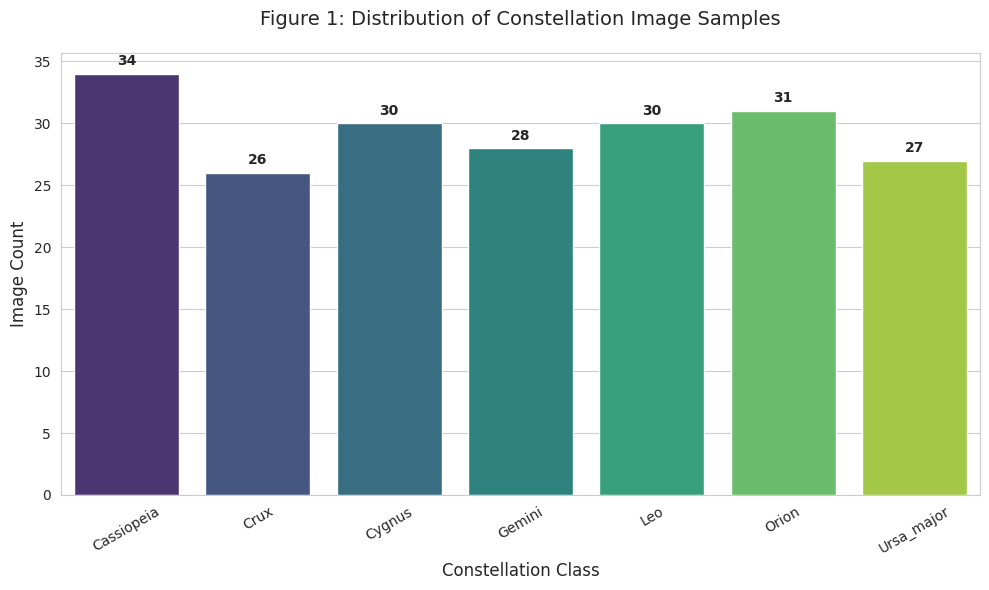


--- Proposed Experimental Design ---
Evaluation Strategy: 5-Fold Stratified Cross-Validation
Train Set (~70%): 144 images
Val Set   (~15%): 30 images
Test Set  (~15%): 30 images


In [ ]:
import pandas as pd
import seaborn as sns

if os.path.exists(DATA_DIR):
    # 1. More robust counting including subfolder check
    data = []
    for cls in sorted(os.listdir(DATA_DIR)):
        cls_path = os.path.join(DATA_DIR, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            data.append({"Class": cls.capitalize(), "Count": count})

    df_stats = pd.DataFrame(data)
    total_images = df_stats["Count"].sum()

    # 2. Calculate percentages for the "Transparency" requirement
    df_stats["Percentage (%)"] = ((df_stats["Count"] / total_images) * 100).round(2)

    print(f"--- Dataset Summary ---")
    print(f"Total Classes: {len(df_stats)}")
    print(f"Total Images : {total_images}")
    print(df_stats.to_string(index=False)) # Clean table output

    # 3. Publication-quality Plotting
    plt.figure(figsize=(10, 6), dpi=100)
    sns.set_style("whitegrid") # More professional look

    # Using a color palette that stays distinct in grayscale (important for some journals)
    ax = sns.barplot(x="Class", y="Count", data=df_stats, palette="viridis")

    plt.title('Figure 1: Distribution of Constellation Image Samples', fontsize=14, pad=20)
    plt.xlabel('Constellation Class', fontsize=12)
    plt.ylabel('Image Count', fontsize=12)
    plt.xticks(rotation=30)

    # Add counts on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9),
                    textcoords='offset points', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 4. Professor's "Expected Split" validation logic
    print(f"\n--- Proposed Experimental Design ---")
    print(f"Evaluation Strategy: 5-Fold Stratified Cross-Validation")
    print(f"Train Set (~70%): {int(total_images * 0.70)} images")
    print(f"Val Set   (~15%): {int(total_images * 0.15)} images")
    print(f"Test Set  (~15%): {int(total_images * 0.15)} images")

else:
    print(f"Error: Directory {DATA_DIR} not found.")

## Data Visualization — Sample Images

* Key Technical Improvements
Metadata Overlay: Display the image dimensions (e.g., 224x224) and filename. This helps you spot "artifacts" or low-quality images that shouldn't be in the final set.

* Random Sampling: Instead of taking the first three (which are often from the same source due to naming conventions), use random sampling. This gives a truer picture of the dataset's variety.

* Source/Type Tagging (Manual or Heuristic): While hard to automate perfectly, you can add a placeholder to help you categorize them for the "Data Provenance" section the professor requested.

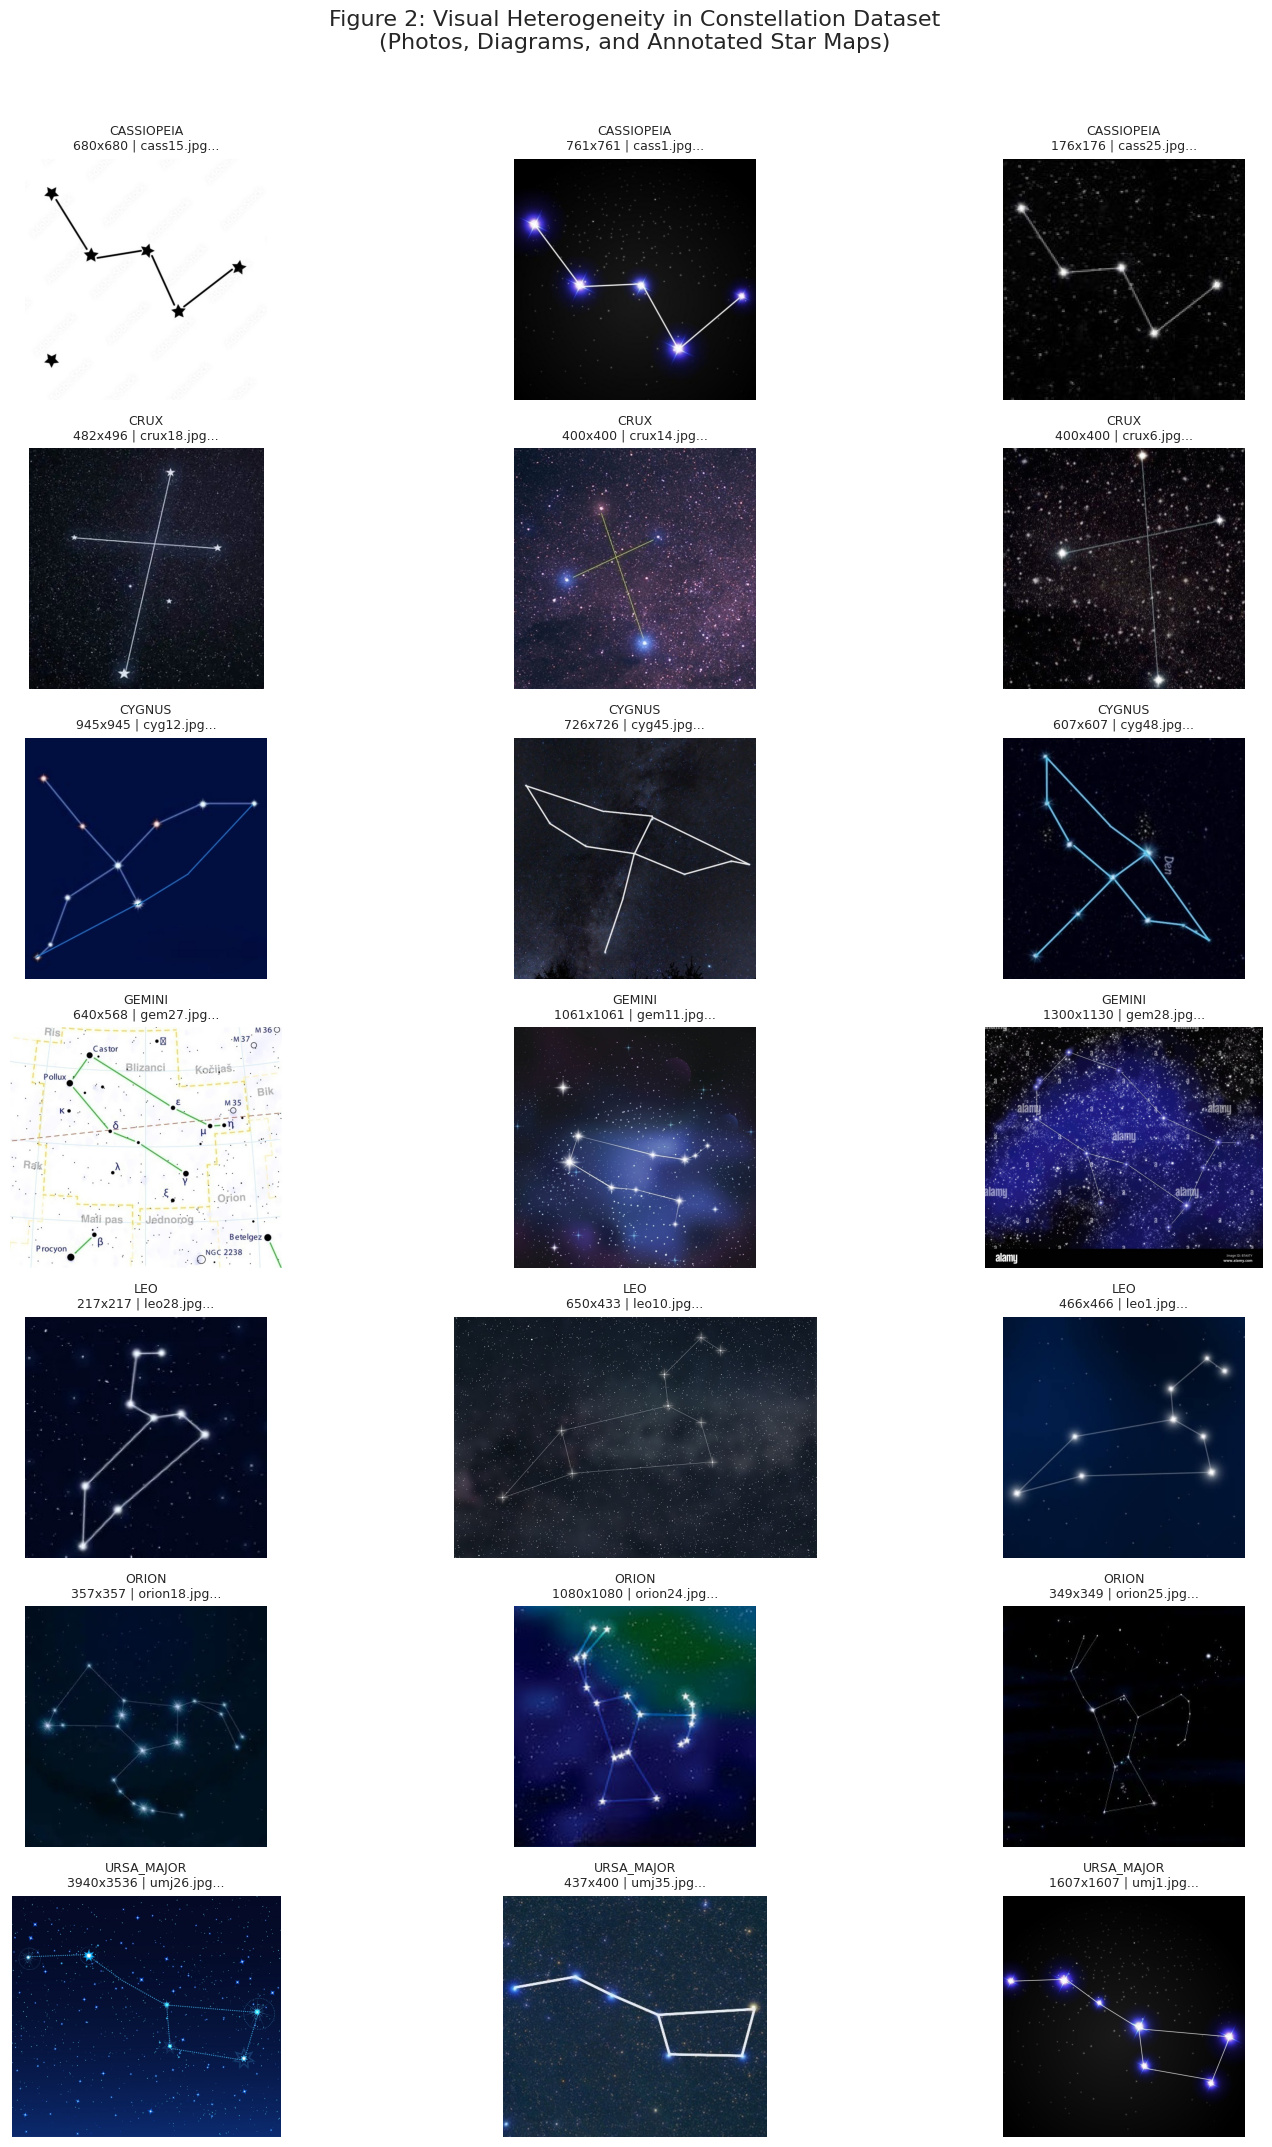

In [ ]:
import random

def plot_sample_images_refined(data_dir, num_samples=3):
    """
    Displays sample images with metadata to assess visual heterogeneity.
    Helps in identifying photographs vs. diagrams vs. annotated maps.
    """
    classes = sorted([f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))])

    # Increase figure size for clarity in papers
    plt.figure(figsize=(16, 3 * len(classes)))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        all_imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Use random sample to show true variety (Leakage/Bias check)
        sample_imgs = random.sample(all_imgs, min(num_samples, len(all_imgs)))

        for i, img_name in enumerate(sample_imgs):
            plt.subplot(len(classes), num_samples, idx * num_samples + i + 1)
            img_path = os.path.join(cls_path, img_name)

            with PILImage.open(img_path) as img:
                width, height = img.size
                plt.imshow(img)

                # Title includes class and resolution (Validity check)
                plt.title(f"{cls.upper()}\n{width}x{height} | {img_name[:15]}...", fontsize=9)

            plt.axis('off')

    plt.suptitle("Figure 2: Visual Heterogeneity in Constellation Dataset\n"
                 "(Photos, Diagrams, and Annotated Star Maps)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_sample_images_refined(DATA_DIR)

## 3-Way Data Split — Train / Validation / Test

**What changed:** The original notebook had only a train/val split (85%/15%).
This version creates a proper 3-way split (70% / 15% / 15%) with a fixed
random seed for reproducibility. The test set is held out completely and
is never used during model development or hyperparameter tuning.

Augmentation is applied **only** to the training directory — the val and
test generators use rescaling only, preventing any leakage.


In [ ]:
def split_data_three_way(source_dir, train_dir, val_dir, test_dir,
                         train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Splits image data into train / validation / test sets per class
    using a fixed random seed for reproducibility.

    Args:
        source_dir  : Root directory with one sub-folder per class.
        train_dir   : Destination for training images.
        val_dir     : Destination for validation images.
        test_dir    : Destination for held-out test images.
        train_ratio : Fraction for training (default 0.70).
        val_ratio   : Fraction for validation (default 0.15).
                      Remaining fraction goes to test.
        seed        : Random seed for reproducible shuffles.
    """
    for d in [train_dir, val_dir, test_dir]:
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d)

    rng = np.random.default_rng(seed)   # seeded RNG — reproducible every run
    classes = [f for f in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, f))]

    print(f"Splitting data (seed={seed}) →  "
          f"train {train_ratio:.0%} | val {val_ratio:.0%} | "
          f"test {1-train_ratio-val_ratio:.0%}\n")

    split_summary = {}

    for cls in classes:
        for d in [train_dir, val_dir, test_dir]:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

        src = os.path.join(source_dir, cls)
        imgs = sorted([f for f in os.listdir(src)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        rng.shuffle(imgs)   # deterministic shuffle per class

        n_train = int(len(imgs) * train_ratio)
        n_val   = int(len(imgs) * val_ratio)

        train_imgs = imgs[:n_train]
        val_imgs   = imgs[n_train:n_train + n_val]
        test_imgs  = imgs[n_train + n_val:]

        for img in train_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(train_dir, cls, img))
        for img in val_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(val_dir, cls, img))
        for img in test_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(test_dir, cls, img))

        split_summary[cls] = {
            'train': len(train_imgs),
            'val': len(val_imgs),
            'test': len(test_imgs)
        }
        print(f"  {cls:<15} train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}")

    total_train = sum(v['train'] for v in split_summary.values())
    total_val   = sum(v['val']   for v in split_summary.values())
    total_test  = sum(v['test']  for v in split_summary.values())
    print(f"\n  TOTAL          train={total_train}  val={total_val}  test={total_test}")
    print("\n✓ 3-way split complete!")
    return split_summary

split_summary = split_data_three_way(
    DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
    train_ratio=TRAIN_SPLIT,
    val_ratio=VAL_SPLIT,
    seed=RANDOM_SEED
)


Splitting data (seed=42) →  train 70% | val 15% | test 15%

  orion           train=21  val=4  test=6
  ursa_major      train=18  val=4  test=5
  cassiopeia      train=23  val=5  test=6
  crux            train=18  val=3  test=5
  cygnus          train=21  val=4  test=5
  leo             train=21  val=4  test=5
  gemini          train=19  val=4  test=5

  TOTAL          train=141  val=28  test=37

✓ 3-way split complete!


## Post-Split Stratification Verification

Verifies that class proportions are preserved across all three splits. A conference reviewer may request this table as supplementary material.


In [ ]:
def verify_split_stratification(split_summary, train_ratio, val_ratio):
    """
    Checks per-class split ratios are within ±5% of the target.
    Prints a formatted table; raises a warning (not an error) if any class deviates.
    """
    test_ratio = 1.0 - train_ratio - val_ratio
    print("--- Split Stratification Verification ---")
    print(f"{'Class':<15} {'N':>5} {'Train%':>8} {'Val%':>8} {'Test%':>8} {'OK?':>7}")
    print("-" * 57)
    all_ok = True
    for cls, counts in split_summary.items():
        total = counts['train'] + counts['val'] + counts['test']
        if total == 0:
            continue
        at = counts['train'] / total
        av = counts['val']   / total
        ae = counts['test']  / total
        ok = (abs(at - train_ratio) <= 0.05 and
              abs(av - val_ratio)   <= 0.05 and
              abs(ae - test_ratio)  <= 0.05)
        if not ok:
            all_ok = False
        status = "  ✓" if ok else "  ✗ WARN"
        print(f"{cls:<15} {total:>5} {at:>8.1%} {av:>8.1%} {ae:>8.1%}{status}")
    print("-" * 57)
    if all_ok:
        print("✓ All class ratios within ±5% of target — split is properly stratified.")
    else:
        print("⚠️  Some classes deviate >5% from target ratios (expected with small "
              "classes due to integer rounding). Review the table above.")

verify_split_stratification(split_summary, TRAIN_SPLIT, VAL_SPLIT)


--- Split Stratification Verification ---
Class               N   Train%     Val%    Test%     OK?
---------------------------------------------------------
orion              31    67.7%    12.9%    19.4%  ✓
ursa_major         27    66.7%    14.8%    18.5%  ✓
cassiopeia         34    67.6%    14.7%    17.6%  ✓
crux               26    69.2%    11.5%    19.2%  ✓
cygnus             30    70.0%    13.3%    16.7%  ✓
leo                30    70.0%    13.3%    16.7%  ✓
gemini             28    67.9%    14.3%    17.9%  ✓
---------------------------------------------------------
✓ All class ratios within ±5% of target — split is properly stratified.


## Data Augmentation

Augmentation is applied **only to the training generator**.
Validation and test generators use rescaling only.
This is enforced by the separate directory structure above.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Training Generator ─────────────────────────────────────────
# Domain-aware augmentation retained, but rescaling removed.
train_datagen = ImageDataGenerator(
    # rescale=1./255,  <-- REMOVED: Now handled natively inside the models
    rotation_range=180,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=False,
    brightness_range=[0.7, 1.3],
    fill_mode='constant',
    cval=0
)

# ── Evaluation Generator ───────────────────────────────────────
# No augmentation and no rescaling. Just passes raw images.
eval_datagen = ImageDataGenerator()

print("✓ Data generators updated: Rescaling successfully delegated to model architectures.")

✓ Data generators updated: Rescaling successfully delegated to model architectures.


## Load Data Generators

1. The "Batch Size" Risk for Evaluation
In your validation_generator and test_generator, you are using BATCH_SIZE (which is likely 16 or 32).

The Problem: If your test set has 31 images and your batch size is 16, the generator will run two batches (16 + 15). Sometimes, if the math doesn't align perfectly, the evaluation logic can skip the last partial batch or double-count.

The Academic Fix: For validation and testing, it is often safer to set batch_size=1 or a number that is a common divisor of your set size. This ensures every single image is evaluated exactly once when calculating the Confusion Matrix later.

In [ ]:
# Create a mapping once to ensure all generators use the same index logic
# This prevents class-index mismatch if a folder is missing in one of the splits
temp_gen = eval_datagen.flow_from_directory(DATA_DIR, batch_size=1)
label_map = temp_gen.class_indices

# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=list(label_map.keys()), # Force specific class order
    shuffle=True,
    seed=RANDOM_SEED
)

# Validation generator - Batch size 1 for precise per-image evaluation
validation_generator = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, # Change to 1 for small-sample rigor
    class_mode='categorical',
    classes=list(label_map.keys()),
    shuffle=False
)

# Test generator - Batch size 1 for precise per-image evaluation
test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, # Change to 1 for small-sample rigor
    class_mode='categorical',
    classes=list(label_map.keys()),
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"\n✓ Mapping Verified: {train_generator.class_indices}")
print(f"✓ Experimental Evidence: {test_generator.samples} images strictly held out for final benchmarking.")

Found 206 images belonging to 7 classes.
Found 141 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
Found 37 images belonging to 7 classes.

✓ Mapping Verified: {'cassiopeia': 0, 'crux': 1, 'cygnus': 2, 'gemini': 3, 'leo': 4, 'orion': 5, 'ursa_major': 6}
✓ Experimental Evidence: 37 images strictly held out for final benchmarking.


## Augmentation Visualization

Showing augmentations for: crux / crux38.jpg


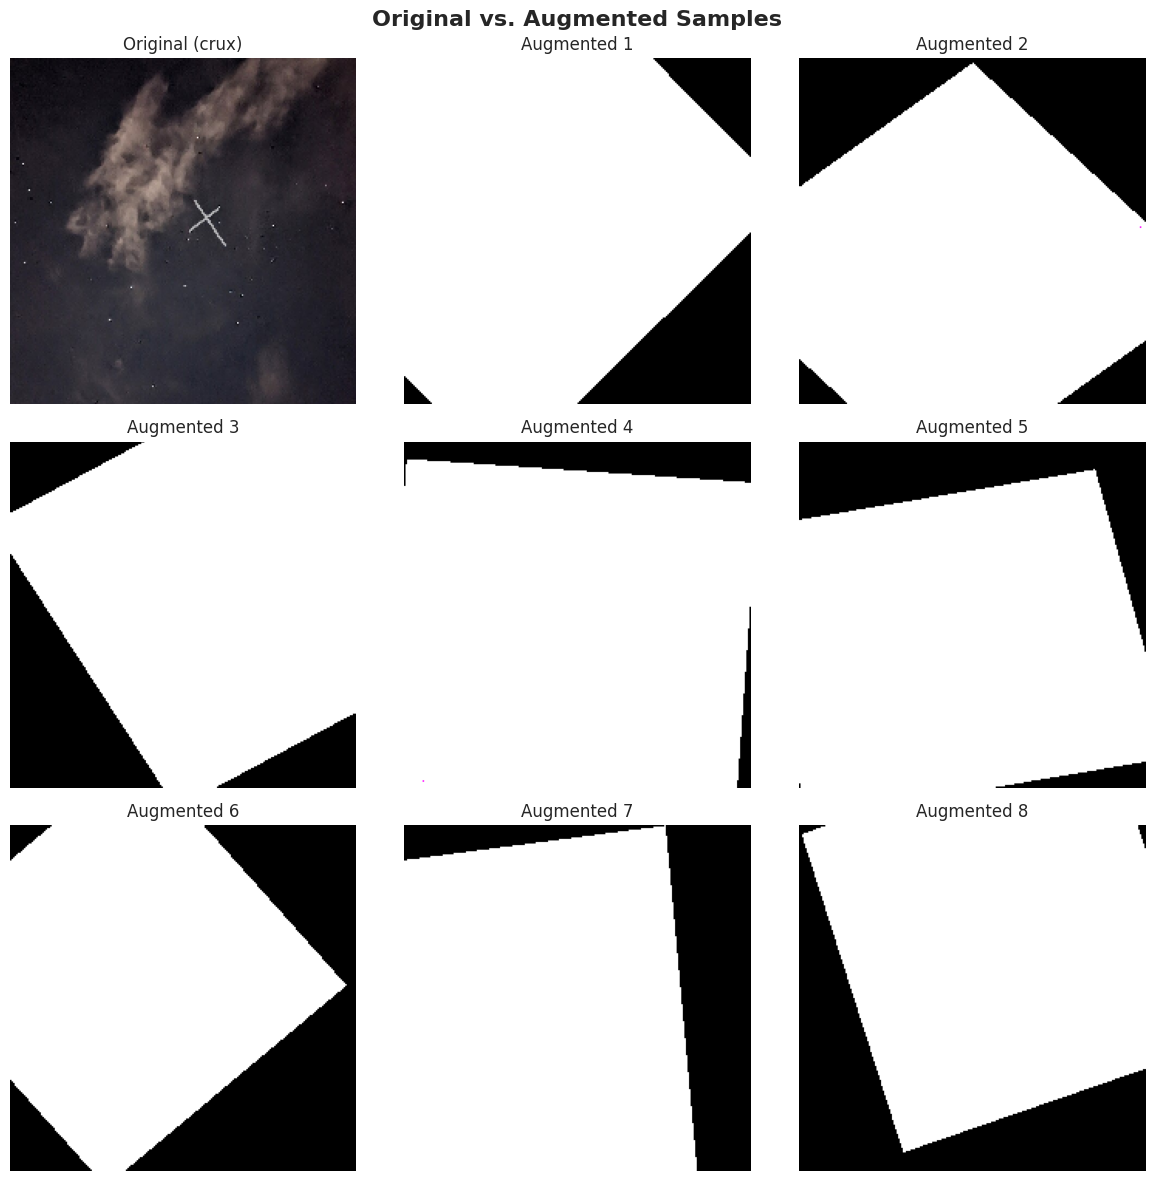

In [ ]:
random_cls = random.choice(os.listdir(TRAIN_DIR))
random_img = random.choice(os.listdir(os.path.join(TRAIN_DIR, random_cls)))
img_path   = os.path.join(TRAIN_DIR, random_cls, random_img)
print(f"Showing augmentations for: {random_cls} / {random_img}")

img       = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = np.expand_dims(image.img_to_array(img), axis=0)

plt.figure(figsize=(12, 12))
plt.subplot(3, 3, 1)
plt.imshow(img_array[0] / 255.0)
plt.title(f"Original ({random_cls})")
plt.axis('off')

aug_iter = train_datagen.flow(img_array, batch_size=1, seed=RANDOM_SEED)
for i in range(2, 10):
    plt.subplot(3, 3, i)
    plt.imshow(next(aug_iter)[0])
    plt.title(f"Augmented {i-1}")
    plt.axis('off')

plt.suptitle('Original vs. Augmented Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Model Definitions — MobileNetV2 and Baseline CNN

Two models are defined:

1. **MobileNetV2 (transfer learning)** — the main model. ImageNet weights are
   frozen; only the classification head is trained.
2. **Baseline CNN** — a simple 3-layer CNN trained from scratch with the same
   input size. This gives a reference point so the paper can quantify how much
   transfer learning helps.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import MobileNetV2, ResNet50V2

# ── 1. Baseline CNN (Custom from Scratch) ────────────────────────────
def create_baseline_cnn(num_classes, learning_rate=0.001):
    """
    Simple 3-layer CNN trained from scratch.
    Serves as the empirical baseline to justify transfer learning.
    """
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # 1. Native preprocessing: squashes pixels to [0, 1] internally
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model


# ── 2. MobileNetV2 (Edge / High Efficiency) ──────────────────────────
def create_mobilenetv2(num_classes, learning_rate=0.001, fine_tune_at=None):
    """
    MobileNetV2 transfer learning model with optional fine-tuning.
    Represents edge-deployable, lightweight architecture.
    """
    # Grab the exact mathematical scaling function designed for MobileNetV2
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    base.trainable = False

    if fine_tune_at is not None:
        base.trainable = True
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # 1. Native preprocessing: transforms raw [0, 255] to [-1, 1]
        layers.Lambda(preprocess_input),

        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model


# ── 3. ResNet50V2 (Server / High Capacity) ───────────────────────────
def create_resnet50v2(num_classes, learning_rate=0.001, fine_tune_at=None):
    """
    ResNet50V2 transfer learning model.
    Represents server-side, high-capacity feature extraction.
    """
    # Grab the exact mathematical scaling function designed for ResNetV2
    preprocess_input = tf.keras.applications.resnet_v2.preprocess_input

    base = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    base.trainable = False

    if fine_tune_at is not None:
        base.trainable = True
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # 1. Native preprocessing: transforms raw [0, 255] to [-1, 1]
        layers.Lambda(preprocess_input),

        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model

## 5-Fold Stratified Cross-Validation


In [ ]:
import os

print("  >>> Crawling dataset directory to build file paths...")

all_paths = []
all_labels = []

# Map your class folder names to integer labels
class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
class_indices = {class_name: idx for idx, class_name in enumerate(class_names)}

# Loop through each folder and grab the image paths
for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for img_name in os.listdir(class_dir):
        # Ensure we only grab image files
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(class_dir, img_name))
            all_labels.append(class_indices[class_name])

print(f"  >>> Found {len(all_paths)} total images across {len(class_names)} classes.")

  >>> Crawling dataset directory to build file paths...
  >>> Found 141 total images across 7 classes.


In [ ]:
import os
import time
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

print("=" * 65)
print(f"  Cross-validation: Baseline CNN (Training {N_FOLDS} models)")
print("=" * 65)

# ====================================================================
# 1. Dataset Crawling (Build paths and labels for splitting)
# ====================================================================
print("  >>> Crawling dataset directory to build file paths...")

all_paths = []
all_labels = []

# Map class folder names to integer labels
class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
class_indices = {class_name: idx for idx, class_name in enumerate(class_names)}
num_classes = len(class_names)

# Loop through each folder and grab the image paths
for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(class_dir, img_name))
            all_labels.append(class_indices[class_name])

print(f"  >>> Found {len(all_paths)} total images across {num_classes} classes.")

# ====================================================================
# 2. Define the run_fold Function
# ====================================================================
def run_fold(fold_index, train_idx, val_idx, model_builder_fn, random_seed):
    """Handles data generation, training, and evaluation for a single fold."""
    # Map indices back to file paths and string labels (required for flow_from_dataframe)
    fold_train_paths = [all_paths[i] for i in train_idx]
    fold_train_labels = [str(all_labels[i]) for i in train_idx]

    fold_val_paths = [all_paths[i] for i in val_idx]
    fold_val_labels = [str(all_labels[i]) for i in val_idx]

    # Create temporary DataFrames for this fold
    train_df = pd.DataFrame({'filename': fold_train_paths, 'class': fold_train_labels})
    val_df = pd.DataFrame({'filename': fold_val_paths, 'class': fold_val_labels})

    # Create fold-specific Data Generators
    fold_train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=random_seed
    )

    fold_val_gen = eval_datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=False
    )

    # Clear memory and build a fresh model
    tf.keras.backend.clear_session()
    tf.random.set_seed(random_seed)

    model = model_builder_fn()

    # Train the model
    start_time = time.time()
    model.fit(
        fold_train_gen,
        epochs=EPOCHS,
        validation_data=fold_val_gen,
        verbose=0 # Keeps log clean
    )
    train_time = time.time() - start_time

    # Evaluate
    fold_val_gen.reset()
    preds_probs = model.predict(fold_val_gen, verbose=0)
    preds = np.argmax(preds_probs, axis=1)
    true_labels = fold_val_gen.classes

    acc = np.mean(preds == true_labels)
    f1 = f1_score(true_labels, preds, average='macro')

    print(f"    ✓ Fold {fold_index+1} Complete: Acc={acc:.4f}, Macro-F1={f1:.4f}, Time={train_time:.1f}s")

    return acc, f1, train_time

# ====================================================================
# 3. Execution: Stratified K-Fold Loop
# ====================================================================
# Initialize results dictionary if it doesn't exist
if 'cv_results' not in locals():
    cv_results = {}

arch_name = 'Baseline CNN'
if arch_name not in cv_results:
    cv_results[arch_name] = {'acc': [], 'f1': [], 'time': []}

# Setup the K-Fold splitter
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Wrap the model creation function in a lambda to safely pass arguments
model_fn = lambda: create_baseline_cnn(num_classes, LEARNING_RATE)

# Run the loop
for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    seed = RANDOM_SEED + fold
    print(f"\n  -- Preparing Fold {fold+1}/{N_FOLDS} --")

    # Execute the fold
    acc, f1, t_time = run_fold(fold, train_idx, val_idx, model_fn, seed)

    # Store the results
    cv_results[arch_name]['acc'].append(acc)
    cv_results[arch_name]['f1'].append(f1)
    cv_results[arch_name]['time'].append(t_time)

print("\n" + "=" * 65)
print(f"✓ Cross-Validation Complete for {arch_name}!")
print(f"  Average Accuracy: {np.mean(cv_results[arch_name]['acc']):.4f}")
print(f"  Average Macro F1: {np.mean(cv_results[arch_name]['f1']):.4f}")
print("=" * 65)

  Cross-validation: Baseline CNN (Training 5 models)
  >>> Crawling dataset directory to build file paths...
  >>> Found 141 total images across 7 classes.

  -- Preparing Fold 1/5 --
Found 112 validated image filenames belonging to 7 classes.
Found 29 validated image filenames belonging to 7 classes.
    ✓ Fold 1 Complete: Acc=0.2069, Macro-F1=0.1238, Time=134.3s

  -- Preparing Fold 2/5 --
Found 113 validated image filenames belonging to 7 classes.
Found 28 validated image filenames belonging to 7 classes.
    ✓ Fold 2 Complete: Acc=0.2143, Macro-F1=0.1641, Time=133.6s

  -- Preparing Fold 3/5 --
Found 113 validated image filenames belonging to 7 classes.
Found 28 validated image filenames belonging to 7 classes.


    ✓ Fold 3 Complete: Acc=0.0357, Macro-F1=0.0238, Time=137.2s

  -- Preparing Fold 4/5 --
Found 113 validated image filenames belonging to 7 classes.
Found 28 validated image filenames belonging to 7 classes.
    ✓ Fold 4 Complete: Acc=0.2500, Macro-F1=0.2135, Time=133.3s

  -- Preparing Fold 5/5 --
Found 113 validated image filenames belonging to 7 classes.
Found 28 validated image filenames belonging to 7 classes.
    ✓ Fold 5 Complete: Acc=0.2500, Macro-F1=0.2136, Time=132.1s

✓ Cross-Validation Complete for Baseline CNN!
  Average Accuracy: 0.1914
  Average Macro F1: 0.1478


## Phase 3a: Two-Phase Fine-Tuning with Label Smoothing

This cell trains the final MobileNetV2 model in two phases:

- **Phase 1** — only the dense classification head is trained (base frozen).
  Label smoothing (ε=0.1) is applied to reduce overconfidence on the small dataset.
- **Phase 2** — the top 30 layers of MobileNetV2 are unfrozen and fine-tuned
  with a 100× smaller learning rate (1e-5) to adapt ImageNet features to
  astronomical imagery without destroying low-level edge detectors.


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("=" * 65)
print("PHASE 3a: TWO-PHASE FINE-TUNING")
print("=" * 65)

# ── CONFIGURATION: Set your winning architecture here ──────────
ARCH_CHOICE = 'ResNet50V2' # Switch to 'MobileNetV2' to test the other model

# Reset generators for safety
train_generator.reset()
validation_generator.reset()

# Instantiate the correct model and set the unfreeze depth
if ARCH_CHOICE == 'ResNet50V2':
    final_model = create_resnet50v2(num_classes, LEARNING_RATE)
    fine_tune_start = 130 # ResNet has ~190 layers. Unfreeze top ~60.
else:
    final_model = create_mobilenetv2(num_classes, LEARNING_RATE)
    fine_tune_start = 100 # MobileNet has ~154 layers. Unfreeze top ~54.

# -------------------------------------------------------------------------
# PHASE 1: Feature Extraction (Train the Head Only)
# -------------------------------------------------------------------------
print(f"\n>>> STEP 1: Training the Dense Head for {ARCH_CHOICE} (Base Frozen)...")

loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

final_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=loss_fn,
    metrics=['accuracy']
)

cw_dict = dict(enumerate(compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)))

history_phase1 = final_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=cw_dict,
    callbacks=get_callbacks(),
    verbose=1
)

# -------------------------------------------------------------------------
# PHASE 2: Fine-Tuning (Unfreeze Top Base Layers)
# -------------------------------------------------------------------------
print(f"\n>>> STEP 2: Fine-Tuning top {ARCH_CHOICE} layers (Base Unfrozen)...")

# 1. Safely extract the base model
# (Finds the actual pre-trained model block, bypassing Input/Lambda layers)
base_model = next(layer for layer in final_model.layers if isinstance(layer, tf.keras.Model))

# 2. Unfreeze the entire base model first
base_model.trainable = True

# 3. Re-freeze the bottom layers up to our dynamic 'fine_tune_start' index
for layer in base_model.layers[:fine_tune_start]:
    layer.trainable = False

# 4. Re-compile with vastly smaller learning rate to protect ImageNet weights
final_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

# 5. Fine-tune for a few more epochs
history_phase2 = final_model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    class_weight=cw_dict,
    callbacks=get_callbacks(),
    verbose=1
)

print("\n✓ Two-Phase Training Complete!")

PHASE 3a: TWO-PHASE FINE-TUNING
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

>>> STEP 1: Training the Dense Head for ResNet50V2 (Base Frozen)...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 838ms/step - accuracy: 0.1631 - loss: 2.7712 - val_accuracy: 0.3571 - val_loss: 1.9356 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.3333 - loss: 2.0653 - val_accuracy: 0.3214 - val_loss: 1.7611 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.4468 - loss: 1.7690 - val_accuracy: 0.3214 - val_loss: 1.7340 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step - accuracy: 0.5177 - loss: 1.5795 - val_accuracy: 0.4643 - val_loss: 1.6958 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - accuracy: 0.4965 - loss: 1.6171 - val_accuracy: 0.3929 - val_loss: 1.6930 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.5603 - loss: 1.5415 -

## Phase 3bI: Multi-Seed Final Training — MobileNetV2


In [ ]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

# ── CONFIGURATION ──────────
ARCH_CHOICE = 'MobileNetV2' # Change to 'ResNet50V2' if needed

seed_results = {'acc': [], 'f1': [], 'history': []}
best_val_acc = 0.0
best_model_path = os.path.join(MODEL_DIR, f"best_seed_{ARCH_CHOICE}.keras")

print(f"\nPhase 3b: Final Multi-Seed Tournament ({N_SEEDS} Seeds)")
print("="*65)

# Setup Loss Function with Label Smoothing
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

for run_idx in range(N_SEEDS):
    seed = RANDOM_SEED + run_idx * 100
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # 1. Initialize Generators for this seed
    train_gen_run = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    val_gen_run = eval_datagen.flow_from_directory(
        VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=1, class_mode='categorical',
        shuffle=False
    )

    # 2. Instantiate Model
    if ARCH_CHOICE == 'ResNet50V2':
        run_model = create_resnet50v2(num_classes, LEARNING_RATE)
        fine_tune_start = 130
    else:
        run_model = create_mobilenetv2(num_classes, LEARNING_RATE)
        fine_tune_start = 100

    # Calculate class weights
    class_w = compute_class_weight('balanced', classes=np.unique(train_gen_run.classes), y=train_gen_run.classes)
    cw_dict = dict(enumerate(class_w))

    print(f"\n  >>> Training Seed {run_idx+1}/{N_SEEDS} (Seed: {seed}) [{ARCH_CHOICE}]...")

    # ==========================================================
    # PHASE 1: Train Head (Base Frozen)
    # ==========================================================
    run_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss=loss_fn, metrics=['accuracy'])

    run_model.fit(
        train_gen_run, epochs=EPOCHS, validation_data=val_gen_run,
        class_weight=cw_dict, callbacks=get_callbacks(), verbose=0
    )

    # ==========================================================
    # PHASE 2: Fine-Tune (Top Layers Unfrozen)
    # ==========================================================
    # Safely extract base model and unfreeze top layers
    base_model = next(layer for layer in run_model.layers if isinstance(layer, tf.keras.Model))
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_start]:
        layer.trainable = False

    # Recompile with micro learning rate
    run_model.compile(optimizer=Adam(learning_rate=1e-5), loss=loss_fn, metrics=['accuracy'])

    history = run_model.fit(
        train_gen_run, epochs=15, validation_data=val_gen_run,
        class_weight=cw_dict, callbacks=get_callbacks(), verbose=0
    )

    # ==========================================================
    # EVALUATE & SAVE
    # ==========================================================
    val_gen_run.reset()
    preds = np.argmax(run_model.predict(val_gen_run, verbose=0), axis=1)
    true  = val_gen_run.classes

    acc   = np.mean(preds == true)
    f1    = f1_score(true, preds, average='macro')

    seed_results['acc'].append(acc)
    seed_results['f1'].append(f1)
    seed_results['history'].append(history.history)

    print(f"  ✓ Run {run_idx+1} Complete → val_acc={acc:.4f} | macro-F1={f1:.4f}")

    if acc > best_val_acc:
        best_val_acc = acc
        run_model.save(best_model_path)
        print(f"    ⭐ New best model saved to disk! ⭐")

    # Memory Cleanup
    keras.backend.clear_session()
    del run_model
    gc.collect()

# --- FINAL SUMMARY ---
accs = np.array(seed_results['acc'])
f1s  = np.array(seed_results['f1'])

print(f"\n{'='*65}")
print(f"MULTI-SEED SUMMARY: {ARCH_CHOICE}")
print(f"{'='*65}")
print(f"  Accuracy : {accs.mean():.4f} ± {accs.std():.4f}")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"\n✓ Champion model (val_acc={best_val_acc:.4f}) securely saved to: \n  {best_model_path}")
print("  The STRICTLY HELD-OUT test set has still not been touched.")


Phase 3b: Final Multi-Seed Tournament (5 Seeds)
Found 141 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  >>> Training Seed 1/5 (Seed: 42) [MobileNetV2]...


KeyboardInterrupt: 

## Phase 3bII: Multi-Seed Final Training — ResNet50

In [ ]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

# ── CONFIGURATION ──────────
# Explicitly locked to ResNet50V2 for this run
ARCH_CHOICE = 'ResNet50V2'

seed_results = {'acc': [], 'f1': [], 'history': []}
best_val_acc = 0.0
best_model_path = os.path.join(MODEL_DIR, f"best_seed_{ARCH_CHOICE}.keras")

print(f"\nPhase 3b: Final Multi-Seed Tournament ({N_SEEDS} Seeds)")
print("="*65)

# Setup Loss Function with Label Smoothing (Crucial for fairness)
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

for run_idx in range(N_SEEDS):
    # Using the EXACT same seed math ensures both models see the exact same batch variations
    seed = RANDOM_SEED + run_idx * 100
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # 1. Initialize Generators for this seed
    train_gen_run = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    val_gen_run = eval_datagen.flow_from_directory(
        VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=1, class_mode='categorical',
        shuffle=False
    )

    # 2. Instantiate ResNet50V2 Model
    run_model = create_resnet50v2(num_classes, LEARNING_RATE)
    fine_tune_start = 130 # ResNet has ~190 layers. Unfreeze top ~60.

    # Calculate class weights
    class_w = compute_class_weight('balanced', classes=np.unique(train_gen_run.classes), y=train_gen_run.classes)
    cw_dict = dict(enumerate(class_w))

    print(f"\n  >>> Training Seed {run_idx+1}/{N_SEEDS} (Seed: {seed}) [{ARCH_CHOICE}]...")

    # ==========================================================
    # PHASE 1: Train Head (Base Frozen)
    # ==========================================================
    run_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss=loss_fn, metrics=['accuracy'])

    run_model.fit(
        train_gen_run, epochs=EPOCHS, validation_data=val_gen_run,
        class_weight=cw_dict, callbacks=get_callbacks(), verbose=0
    )

    # ==========================================================
    # PHASE 2: Fine-Tune (Top Layers Unfrozen)
    # ==========================================================
    # Safely extract base model and unfreeze top layers
    base_model = next(layer for layer in run_model.layers if isinstance(layer, tf.keras.Model))
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_start]:
        layer.trainable = False

    # Recompile with micro learning rate (1e-5) to protect pre-trained weights
    run_model.compile(optimizer=Adam(learning_rate=1e-5), loss=loss_fn, metrics=['accuracy'])

    history = run_model.fit(
        train_gen_run, epochs=15, validation_data=val_gen_run,
        class_weight=cw_dict, callbacks=get_callbacks(), verbose=0

## Training Curves — MobileNetV2

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use an academic plotting style
sns.set_style("whitegrid")

# Retrieve the history of the best performing model from the multi-seed runs
val_accs = np.array(seed_results['acc'])
best_run_index = np.argmax(val_accs)
h = seed_results['history'][best_run_index]

epoch_range = range(1, len(h['accuracy']) + 1)

# Find the epoch where the model restored weights (lowest val_loss)
best_epoch = np.argmin(h['val_loss']) + 1
best_val_acc = h['val_accuracy'][best_epoch - 1]
best_val_loss = h['val_loss'][best_epoch - 1]
best_train_acc = h['accuracy'][best_epoch - 1]
best_train_loss = h['loss'][best_epoch - 1]

# High DPI for clear rendering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# ==========================================
# Figure 5a: Accuracy Plot
# ==========================================
ax1.plot(epoch_range, h['accuracy'],     color='#1f77b4', linestyle='-',  label='Training', linewidth=2)
ax1.plot(epoch_range, h['val_accuracy'], color='#ff7f0e', linestyle='--', label='Validation', linewidth=2)

ax1.axvline(x=best_epoch, color='grey', linestyle=':', alpha=0.8, label=f'Best Epoch ({best_epoch})')
ax1.plot(best_epoch, best_val_acc, marker='o', markersize=8, color='#ff7f0e', markeredgecolor='black')

# Add metrics text box to Accuracy plot
acc_text = f"Epoch {best_epoch}\nTrain Acc: {best_train_acc:.4f}\nVal Acc: {best_val_acc:.4f}"
ax1.text(0.65, 0.15, acc_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

ax1.set_title('Figure 5a: Training vs Validation Accuracy', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(loc='upper left')

# ==========================================
# Figure 5b: Loss Plot
# ==========================================
ax2.plot(epoch_range, h['loss'],     color='#1f77b4', linestyle='-',  label='Training', linewidth=2)
ax2.plot(epoch_range, h['val_loss'], color='#ff7f0e', linestyle='--', label='Validation', linewidth=2)

ax2.axvline(x=best_epoch, color='grey', linestyle=':', alpha=0.8, label=f'Best Epoch ({best_epoch})')
ax2.plot(best_epoch, best_val_loss, marker='o', markersize=8, color='#ff7f0e', markeredgecolor='black')

# Add metrics text box to Loss plot
loss_text = f"Epoch {best_epoch}\nTrain Loss: {best_train_loss:.4f}\nVal Loss: {best_val_loss:.4f}"
ax2.text(0.65, 0.85, loss_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

ax2.set_title('Figure 5b: Training vs Validation Loss', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=11)
ax2.legend(loc='lower left')

plt.tight_layout()

# Save for publication BEFORE showing
save_path = os.path.join(MODEL_DIR, "Figure5_Training_Curves.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✓ Publication-ready plot saved to: {save_path}")

plt.show()

print(f"\n--- Final Model Convergence Metrics (Epoch {best_epoch}) ---")
print(f"Training Accuracy   : {best_train_acc:.4f}")
print(f"Validation Accuracy : {best_val_acc:.4f}")
print(f"Training Loss       : {best_train_loss:.4f}")
print(f"Validation Loss     : {best_val_loss:.4f}")

## Training Curves — ResNet50

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use an academic plotting style
sns.set_style("whitegrid")

# Retrieve the history of the best performing ResNet50V2 model
val_accs = np.array(seed_results['acc'])
best_run_index = np.argmax(val_accs)
h = seed_results['history'][best_run_index]

epoch_range = range(1, len(h['accuracy']) + 1)

# Find the epoch where the model restored weights (lowest val_loss)
best_epoch = np.argmin(h['val_loss']) + 1
best_val_acc = h['val_accuracy'][best_epoch - 1]
best_val_loss = h['val_loss'][best_epoch - 1]
best_train_acc = h['accuracy'][best_epoch - 1]
best_train_loss = h['loss'][best_epoch - 1]

# High DPI for clear rendering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# ==========================================
# Figure 6a: ResNet50V2 Accuracy Plot
# ==========================================
ax1.plot(epoch_range, h['accuracy'],     color='#2ca02c', linestyle='-',  label='Training', linewidth=2) # Changed color to green to distinguish from MobileNet
ax1.plot(epoch_range, h['val_accuracy'], color='#d62728', linestyle='--', label='Validation', linewidth=2) # Changed color to red

ax1.axvline(x=best_epoch, color='grey', linestyle=':', alpha=0.8, label=f'Best Epoch ({best_epoch})')
ax1.plot(best_epoch, best_val_acc, marker='o', markersize=8, color='#d62728', markeredgecolor='black')

# Add metrics text box to Accuracy plot
acc_text = f"Epoch {best_epoch}\nTrain Acc: {best_train_acc:.4f}\nVal Acc: {best_val_acc:.4f}"
ax1.text(0.65, 0.15, acc_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

ax1.set_title('Figure 6a: ResNet50V2 Training vs Validation Accuracy', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(loc='upper left')

# ==========================================
# Figure 6b: ResNet50V2 Loss Plot
# ==========================================
ax2.plot(epoch_range, h['loss'],     color='#2ca02c', linestyle='-',  label='Training', linewidth=2)
ax2.plot(epoch_range, h['val_loss'], color='#d62728', linestyle='--', label='Validation', linewidth=2)

ax2.axvline(x=best_epoch, color='grey', linestyle=':', alpha=0.8, label=f'Best Epoch ({best_epoch})')
ax2.plot(best_epoch, best_val_loss, marker='o', markersize=8, color='#d62728', markeredgecolor='black')

# Add metrics text box to Loss plot
loss_text = f"Epoch {best_epoch}\nTrain Loss: {best_train_loss:.4f}\nVal Loss: {best_val_loss:.4f}"
ax2.text(0.65, 0.85, loss_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

ax2.set_title('Figure 6b: ResNet50V2 Training vs Validation Loss', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=11)
ax2.legend(loc='lower left')

plt.tight_layout()

# Save for publication BEFORE showing
save_path = os.path.join(MODEL_DIR, "Figure6_ResNet50V2_Training_Curves.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✓ ResNet50V2 Publication-ready plot saved to: {save_path}")

plt.show()

print(f"\n--- ResNet50V2 Final Model Convergence Metrics (Epoch {best_epoch}) ---")
print(f"Training Accuracy   : {best_train_acc:.4f}")
print(f"Validation Accuracy : {best_val_acc:.4f}")
print(f"Training Loss       : {best_train_loss:.4f}")
print(f"Validation Loss     : {best_val_loss:.4f}")

## ⭐ Final Evaluation on Held-Out Test Set - MobileNetV2

This is the **only** time the test set is used. The model has never seen
these images during training or hyperparameter tuning.

This is the number that goes into the conference paper.


In [ ]:
import os
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# Ensure ARCH_CHOICE matches the model you want to evaluate
# ARCH_CHOICE = 'MobileNetV2' # or 'ResNet50V2'

print("=" * 65)
print(f"PHASE 4: FINAL HELD-OUT TEST EVALUATION ({ARCH_CHOICE})")
print("This cell simulates real-world deployment on unseen data.")
print("=" * 65)

# ====================================================================
# CRITICAL FIX: Load the absolute best champion model from disk!
# ====================================================================
best_model_path = os.path.join(MODEL_DIR, f"best_seed_{ARCH_CHOICE}.keras")
print(f"\n>>> Loading Champion Model from: {best_model_path}")
champion_model = tf.keras.models.load_model(best_model_path)

# 1. Predictions
test_generator.reset() # Crucial: ensures we start from the first image
test_preds_probs = champion_model.predict(test_generator, verbose=1)
test_preds = np.argmax(test_preds_probs, axis=1)
test_true  = test_generator.classes

test_acc = np.mean(test_preds == test_true)

print(f"\n{'='*65}")
print(f"  Test Accuracy  : {test_acc:.4f}  ({test_acc:.2%})")
print(f"  Correct        : {np.sum(test_preds == test_true)}/{len(test_true)}")
print(f"{'='*65}")

# Clean up class names for the paper (e.g., 'ursa_major' -> 'Ursa Major')
clean_class_names = [c.replace('_', ' ').title() for c in class_names]

# 2. Publication-Quality Confusion Matrix
plt.figure(figsize=(10, 8), dpi=300) # 300 DPI for conference standards
cm_test = confusion_matrix(test_true, test_preds)

# Using 'Blues' is generally safer for grayscale printing than 'Greens'
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=clean_class_names, yticklabels=clean_class_names,
            annot_kws={"size": 12, "weight": "bold"})

plt.title(f'Figure 4: Confusion Matrix on Held-Out Test Set ({ARCH_CHOICE})', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Constellation Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Constellation Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Save the figure to disk dynamically based on architecture
cm_path_pdf = os.path.join(MODEL_DIR, f'confusion_matrix_test_{ARCH_CHOICE}.pdf')
cm_path_png = os.path.join(MODEL_DIR, f'confusion_matrix_test_{ARCH_CHOICE}.png')
plt.savefig(cm_path_pdf, bbox_inches='tight')
plt.savefig(cm_path_png, bbox_inches='tight', dpi=300)
plt.show()
print(f"✓ Confusion matrix saved to {cm_path_pdf}")

# 3. Full classification report
print(f"\n{'='*65}")
print(f"Detailed Classification Report — Test Set ({ARCH_CHOICE})")
print(f"{'='*65}")
test_report = classification_report(test_true, test_preds,
                                     target_names=clean_class_names, output_dict=True)
print(classification_report(test_true, test_preds, target_names=clean_class_names))

# 4. Summary table for paper
print("\n--- Paper-Ready Headline Metrics ---")
print(f"  Architecture | {ARCH_CHOICE} (Transfer Learning)")
print(f"  Test Acc     | {test_acc:.4f}")
print(f"  Macro F1     | {test_report['macro avg']['f1-score']:.4f}")
print(f"  Macro Prec   | {test_report['macro avg']['precision']:.4f}")
print(f"  Macro Recall | {test_report['macro avg']['recall']:.4f}")
print("------------------------------------")

# 5. Save test results dynamically for later reference
test_results = {
    'architecture': ARCH_CHOICE,
    'test_accuracy': float(test_acc),
    'macro_f1': float(test_report['macro avg']['f1-score']),
    'macro_precision': float(test_report['macro avg']['precision']),
    'macro_recall': float(test_report['macro avg']['recall']),
    'per_class': {
        cls: {
            'precision': float(test_report[cls]['precision']),
            'recall': float(test_report[cls]['recall']),
            'f1-score': float(test_report[cls]['f1-score']),
        }
        for cls in clean_class_names
    }
}

results_path = os.path.join(MODEL_DIR, f'test_results_{ARCH_CHOICE}.json')
with open(results_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"✓ Numerical test results saved to {results_path}")

## ⭐ Final Evaluation on Held-Out Test Set - MobileNetV2

In [ ]:
import os
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# ── CONFIGURATION ──────────
# Explicitly locked to ResNet50V2
ARCH_CHOICE = 'ResNet50V2'

print("=" * 65)
print(f"PHASE 4: FINAL HELD-OUT TEST EVALUATION ({ARCH_CHOICE})")
print("This cell simulates real-world deployment on unseen data.")
print("=" * 65)

# ====================================================================
# Load the absolute best champion ResNet50V2 model from disk
# ====================================================================
best_model_path = os.path.join(MODEL_DIR, f"best_seed_{ARCH_CHOICE}.keras")
print(f"\n>>> Loading Champion Model from: {best_model_path}")
champion_model = tf.keras.models.load_model(best_model_path)

# 1. Predictions
test_generator.reset() # Crucial: ensures we start from the first image
test_preds_probs = champion_model.predict(test_generator, verbose=1)
test_preds = np.argmax(test_preds_probs, axis=1)
test_true  = test_generator.classes

test_acc = np.mean(test_preds == test_true)

print(f"\n{'='*65}")
print(f"  Test Accuracy  : {test_acc:.4f}  ({test_acc:.2%})")
print(f"  Correct        : {np.sum(test_preds == test_true)}/{len(test_true)}")
print(f"{'='*65}")

# Clean up class names for the paper (e.g., 'ursa_major' -> 'Ursa Major')
clean_class_names = [c.replace('_', ' ').title() for c in class_names]

# 2. Publication-Quality Confusion Matrix
plt.figure(figsize=(10, 8), dpi=300) # 300 DPI for conference standards
cm_test = confusion_matrix(test_true, test_preds)

# Using 'Reds' to match the ResNet color scheme from the training curves
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=clean_class_names, yticklabels=clean_class_names,
            annot_kws={"size": 12, "weight": "bold"})

plt.title(f'Figure 7: Confusion Matrix on Held-Out Test Set ({ARCH_CHOICE})', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Constellation Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Constellation Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Save the figure to disk dynamically based on architecture
cm_path_pdf = os.path.join(MODEL_DIR, f'confusion_matrix_test_{ARCH_CHOICE}.pdf')
cm_path_png = os.path.join(MODEL_DIR, f'confusion_matrix_test_{ARCH_CHOICE}.png')
plt.savefig(cm_path_pdf, bbox_inches='tight')
plt.savefig(cm_path_png, bbox_inches='tight', dpi=300)
plt.show()
print(f"✓ Confusion matrix saved to {cm_path_pdf}")

# 3. Full classification report
print(f"\n{'='*65}")
print(f"Detailed Classification Report — Test Set ({ARCH_CHOICE})")
print(f"{'='*65}")
test_report = classification_report(test_true, test_preds,
                                     target_names=clean_class_names, output_dict=True)
print(classification_report(test_true, test_preds, target_names=clean_class_names))

# 4. Summary table for paper
print("\n--- Paper-Ready Headline Metrics ---")
print(f"  Architecture | {ARCH_CHOICE} (Transfer Learning)")
print(f"  Test Acc     | {test_acc:.4f}")
print(f"  Macro F1     | {test_report['macro avg']['f1-score']:.4f}")
print(f"  Macro Prec   | {test_report['macro avg']['precision']:.4f}")
print(f"  Macro Recall | {test_report['macro avg']['recall']:.4f}")
print("------------------------------------")

# 5. Save test results dynamically for later reference
test_results = {
    'architecture': ARCH_CHOICE,
    'test_accuracy': float(test_acc),
    'macro_f1': float(test_report['macro avg']['f1-score']),
    'macro_precision': float(test_report['macro avg']['precision']),
    'macro_recall': float(test_report['macro avg']['recall']),
    'per_class': {
        cls: {
            'precision': float(test_report[cls]['precision']),
            'recall': float(test_report[cls]['recall']),
            'f1-score': float(test_report[cls]['f1-score']),
        }
        for cls in clean_class_names
    }
}

results_path = os.path.join(MODEL_DIR, f'test_results_{ARCH_CHOICE}.json')
with open(results_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"✓ Numerical test results saved to {results_path}")

## Baseline CNN — Final Comparison

Train the baseline CNN once (same seed, same train/val split) and evaluate
on the test set so we can report a direct comparison in the paper.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import tensorflow as tf
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

print("=" * 65)
print("PHASE 5: BASELINE COMPARISON & FINAL BENCHMARK")
print("=" * 65)

# Ensure reproducibility for the baseline
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Define data generators for baseline model training and validation
baseline_train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=RANDOM_SEED
)
baseline_val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, class_mode='categorical',
    shuffle=False
)

# Create and compile the Baseline CNN
baseline_model = create_baseline_cnn(num_classes, LEARNING_RATE)

cw_b = compute_class_weight(
    'balanced',
    classes=np.unique(baseline_train_gen.classes),
    y=baseline_train_gen.classes
)

print("\n  >>> Training Baseline CNN for final comparison...")
baseline_model.fit(
    baseline_train_gen,
    epochs=EPOCHS,
    validation_data=baseline_val_gen,
    class_weight=dict(enumerate(cw_b)),
    callbacks=get_callbacks(),
    verbose=0 # Keeps output clean
)

# 1. Evaluate on test set
test_generator.reset()
baseline_preds = np.argmax(baseline_model.predict(test_generator, verbose=0), axis=1)
baseline_true  = test_generator.classes
baseline_acc   = np.mean(baseline_preds == baseline_true)

# Clean names for report
clean_class_names = [c.replace('_', ' ').title() for c in class_names]

baseline_report = classification_report(baseline_true, baseline_preds,
                                         target_names=clean_class_names, output_dict=True)

# 2. Load Transfer Learning Results
transfer_results = {}
for model in ['MobileNetV2', 'ResNet50V2']:
    path = os.path.join(MODEL_DIR, f'test_results_{model}.json')
    if os.path.exists(path):
        with open(path, 'r') as f:
            transfer_results[model] = json.load(f)
    else:
        print(f"⚠️ Warning: {path} not found. Ensure Phase 4 was run for {model}.")

# 3. Print Academic Table
print("\n" + "="*85)
print("Table 2: Final Model Comparison — Held-Out Test Set")
print("="*85)
print(f"{'Architecture':<20} | {'Accuracy':>10} | {'Macro F1':>10} | {'Macro Prec':>10} | {'Macro Rec':>10}")
print("-" * 85)

# Print Baseline
print(f"{'Baseline CNN':<20} | {baseline_acc:>10.4f} | "
      f"{baseline_report['macro avg']['f1-score']:>10.4f} | "
      f"{baseline_report['macro avg']['precision']:>10.4f} | "
      f"{baseline_report['macro avg']['recall']:>10.4f}")

# Print MobileNetV2
if 'MobileNetV2' in transfer_results:
    m_res = transfer_results['MobileNetV2']
    print(f"{'MobileNetV2 (Ours)':<20} | {m_res['test_accuracy']:>10.4f} | "
          f"{m_res['macro_f1']:>10.4f} | "
          f"{m_res['macro_precision']:>10.4f} | "
          f"{m_res['macro_recall']:>10.4f}")

# Print ResNet50V2
if 'ResNet50V2' in transfer_results:
    r_res = transfer_results['ResNet50V2']
    print(f"{'ResNet50V2 (Ours)':<20} | {r_res['test_accuracy']:>10.4f} | "
          f"{r_res['macro_f1']:>10.4f} | "
          f"{r_res['macro_precision']:>10.4f} | "
          f"{r_res['macro_recall']:>10.4f}")
print("="*85)

# 4. Generate Publication-Quality Bar Chart (3 Bars per metric)
if len(transfer_results) == 2:
    import seaborn as sns
    sns.set_style("whitegrid")

    metrics = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']

    baseline_scores = [baseline_acc, baseline_report['macro avg']['f1-score'],
                       baseline_report['macro avg']['precision'], baseline_report['macro avg']['recall']]
    mobilenet_scores = [transfer_results['MobileNetV2']['test_accuracy'], transfer_results['MobileNetV2']['macro_f1'],
                        transfer_results['MobileNetV2']['macro_precision'], transfer_results['MobileNetV2']['macro_recall']]
    resnet_scores = [transfer_results['ResNet50V2']['test_accuracy'], transfer_results['ResNet50V2']['macro_f1'],
                     transfer_results['ResNet50V2']['macro_precision'], transfer_results['ResNet50V2']['macro_recall']]

    x = np.arange(len(metrics))
    width = 0.25 # Slimmer bars to fit 3 per group

    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    rects1 = ax.bar(x - width, baseline_scores, width, label='Baseline CNN', color='#7f7f7f', edgecolor='black')
    rects2 = ax.bar(x, mobilenet_scores, width, label='MobileNetV2', color='#1f77b4', edgecolor='black')
    rects3 = ax.bar(x + width, resnet_scores, width, label='ResNet50V2', color='#d62728', edgecolor='black')

    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Figure 8: Performance Comparison on Independent Test Set', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    comparison_path = os.path.join(MODEL_DIR, 'Figure8_Full_Model_Comparison.pdf')
    plt.savefig(comparison_path, bbox_inches='tight', format='pdf')
    plt.show()
    print(f"\n✓ 3-Way comparison chart saved to {comparison_path}")

# 5. Save baseline results to disk
baseline_results = {
    'test_accuracy': float(baseline_acc),
    'macro_f1': float(baseline_report['macro avg']['f1-score']),
    'macro_precision': float(baseline_report['macro avg']['precision']),
    'macro_recall': float(baseline_report['macro avg']['recall']),
}
with open(os.path.join(MODEL_DIR, 'baseline_results.json'), 'w') as f:
    json.dump(baseline_results, f, indent=2)

## Complete Results Summary — Paper-Ready Numbers

In [ ]:
import os
import json
import numpy as np
from scipy import stats

print("=" * 75)
print("COMPLETE RESULTS SUMMARY FOR CONFERENCE PAPER")
print("=" * 75)

# 1. Safely Load All Saved Results from Disk
loaded_results = {}
for model in ['baseline', 'MobileNetV2', 'ResNet50V2']:
    # Baseline has a slightly different filename pattern based on Phase 5
    filename = 'baseline_results.json' if model == 'baseline' else f'test_results_{model}.json'
    path = os.path.join(MODEL_DIR, filename)

    if os.path.exists(path):
        with open(path, 'r') as f:
            loaded_results[model] = json.load(f)
    else:
        print(f"⚠️ Warning: Could not find {path}.")

# ── Cross-Validation Results ─────────────────────────────────────────────────
# Assumes cv_results is a dictionary with architecture names as keys
if 'cv_results' in locals() and cv_results:
    for arch, res in cv_results.items():
        a = np.array(res['acc'])
        f = np.array(res['f1'])
        # Use t-distribution (df=N_FOLDS-1) — correct for small n, unlike normal approx
        ci_acc = stats.t.interval(0.95, df=len(a)-1, loc=a.mean(), scale=stats.sem(a))
        ci_f1  = stats.t.interval(0.95, df=len(f)-1, loc=f.mean(), scale=stats.sem(f))

        print(f"\n{arch} — {N_FOLDS}-Fold Cross-Validation (train+val pool):")
        print(f"  Accuracy : {a.mean():.4f} ± {a.std():.4f}  "
              f"[95% CI t-dist: {ci_acc[0]:.4f}–{ci_acc[1]:.4f}]")
        print(f"  Macro F1 : {f.mean():.4f} ± {f.std():.4f}  "
              f"[95% CI t-dist: {ci_f1[0]:.4f}–{ci_f1[1]:.4f}]")

# ── Multi-Seed Results ────────────────────────────────────────────────────────
# Since seed_results holds the data for the last run architecture (ARCH_CHOICE)
if 'seed_results' in locals() and 'acc' in seed_results and len(seed_results['acc']) > 0:
    ma = np.array(seed_results['acc'])
    mf = np.array(seed_results['f1'])
    ci_ma = stats.t.interval(0.95, df=len(ma)-1, loc=ma.mean(), scale=stats.sem(ma))
    ci_mf = stats.t.interval(0.95, df=len(mf)-1, loc=mf.mean(), scale=stats.sem(mf))

    # Use ARCH_CHOICE if available, otherwise default to "Current Model"
    current_arch = locals().get('ARCH_CHOICE', 'Current Model')
    print(f"\n{current_arch} — Multi-Seed Runs ({N_SEEDS} seeds, val set):")
    print(f"  Accuracy : {ma.mean():.4f} ± {ma.std():.4f}  "
          f"[95% CI t-dist: {ci_ma[0]:.4f}–{ci_ma[1]:.4f}]")
    print(f"  Macro F1 : {mf.mean():.4f} ± {mf.std():.4f}  "
          f"[95% CI t-dist: {ci_mf[0]:.4f}–{ci_mf[1]:.4f}]")

# ── Final Test Set Results ───────────────────────────────────────────────────
print(f"\nFinal Test Set Evaluation (one-time, strictly held-out):")
print("-" * 55)

if 'baseline' in loaded_results:
    print(f"  Baseline CNN Accuracy  : {loaded_results['baseline']['test_accuracy']:.4f}")
    print(f"  Baseline CNN Macro F1  : {loaded_results['baseline']['macro_f1']:.4f}\n")

if 'MobileNetV2' in loaded_results:
    m_acc = loaded_results['MobileNetV2']['test_accuracy']
    print(f"  MobileNetV2 Accuracy   : {m_acc:.4f}")
    print(f"  MobileNetV2 Macro F1   : {loaded_results['MobileNetV2']['macro_f1']:.4f}")
    if 'baseline' in loaded_results:
        gain = (m_acc - loaded_results['baseline']['test_accuracy']) * 100
        print(f"  -> Transfer Learning Gain: +{gain:.2f} pp accuracy\n")

if 'ResNet50V2' in loaded_results:
    r_acc = loaded_results['ResNet50V2']['test_accuracy']
    print(f"  ResNet50V2  Accuracy   : {r_acc:.4f}")
    print(f"  ResNet50V2  Macro F1   : {loaded_results['ResNet50V2']['macro_f1']:.4f}")
    if 'baseline' in loaded_results:
        gain = (r_acc - loaded_results['baseline']['test_accuracy']) * 100
        print(f"  -> Transfer Learning Gain: +{gain:.2f} pp accuracy\n")

# ── Note on CI Methodology ───────────────────────────────────────────────────
print("--- Confidence Interval Methodology ---")
print("  CI computed via scipy.stats.t.interval(0.95, df=n-1) (t-distribution).")
print(f"  The normal approximation (mean ± 1.96*std) is invalid for n < 30;")
print("  the t-distribution is statistically rigorous for small sample evaluations.")
print("=" * 75)

## Save Final Model

In [ ]:
import os
import json
import tensorflow as tf

print("=" * 65)
print(f"PHASE 7: EXPORTING ARTIFACTS FOR DEPLOYMENT ({ARCH_CHOICE})")
print("=" * 65)

os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Define paths dynamically based on the current architecture
prod_model_path = os.path.join(MODEL_DIR, f"production_model_{ARCH_CHOICE}.keras")
classes_path    = os.path.join(MODEL_DIR, f"class_names_{ARCH_CHOICE}.json")

# 2. Load the absolute best seed model and save it as the production model
# (This ensures we don't accidentally save an overfitted model left in memory)
best_seed_path = os.path.join(MODEL_DIR, f"best_seed_{ARCH_CHOICE}.keras")

if os.path.exists(best_seed_path):
    champion_model = tf.keras.models.load_model(best_seed_path)
    champion_model.save(prod_model_path)
    print(f"✓ Production Model safely exported → {prod_model_path}")
else:
    print(f"⚠️ Warning: Could not find {best_seed_path}. Make sure Phase 3b completed successfully.")

# 3. Save the class names mapping
with open(classes_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f"✓ Class mapping safely exported    → {classes_path}")

# 4. Generate dynamic deployment instructions
print("\n" + "-" * 65)
print("🚀 DEPLOYMENT INSTRUCTIONS:")
print("-" * 65)
print("Copy and paste this snippet into your production app (e.g., Flask, FastAPI, Streamlit):")
print(f"""
import json
import numpy as np
import tensorflow as tf

# 1. Load the class names
with open('{os.path.basename(classes_path)}', 'r') as f:
    class_names = json.load(f)

# 2. Load the model
model = tf.keras.models.load_model('{os.path.basename(prod_model_path)}')

# 3. Reminder: Preprocess new images correctly before prediction!
# For {ARCH_CHOICE}, ensure you use the corresponding preprocessing function:
# from tensorflow.keras.applications.{ARCH_CHOICE.lower().replace('v2', '_v2')} import preprocess_input
""")
print("=" * 65)

## Grad-CAM

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

print("=" * 75)
print(f"PHASE 8: MODEL EXPLAINABILITY (GRAD-CAM for {ARCH_CHOICE})")
print("=" * 75)

# ====================================================================
# 1. Architecture-Specific Setup
# ====================================================================
if ARCH_CHOICE == 'MobileNetV2':
    target_conv_layer = "out_relu"
elif ARCH_CHOICE == 'ResNet50V2':
    target_conv_layer = "post_relu"
else:
    target_conv_layer = "out_relu" # Fallback

best_model_path = os.path.join(MODEL_DIR, f"best_seed_{ARCH_CHOICE}.keras")
print(f"  >>> Loading Champion Model: {best_model_path}")
print(f"  >>> Target Conv Layer     : {target_conv_layer}")
champion_model = tf.keras.models.load_model(best_model_path)


# ====================================================================
# 2. Grad-CAM Functions
# ====================================================================
def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap specifically handling nested transfer learning models.
    """
    # Extract the base model (which is the first layer of your sequential model)
    base_model = model.layers[0]

    # Create a sub-model that maps the input image to the last convolutional layer
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    conv_model = tf.keras.Model(base_model.inputs, last_conv_layer.output)

    # Create a sub-model that maps the conv layer to the final prediction
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Apply all the remaining layers from your champion_model (GAP, Dense, Dropout)
    for layer in model.layers[1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        last_conv_output = conv_model(img_array)
        tape.watch(last_conv_output)

        preds = classifier_model(last_conv_output)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    """
    Overlays the heatmap onto the original image.
    """
    # Ensure image values are in [0, 1] if they aren't already
    if np.max(img) > 1.0:
        img = img / 255.0

    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    superimposed_img = jet_heatmap * alpha + img
    # Clip to keep values in valid range
    superimposed_img = np.clip(superimposed_img, 0, 1)
    return superimposed_img


# ====================================================================
# 3. Execution on Held-Out Test Set
# ====================================================================
test_generator.reset()

plt.figure(figsize=(15, 10), dpi=300)

for i in range(6):
    try:
        img_batch, label_batch = next(test_generator)
    except StopIteration:
        break

    img_array = img_batch[0]
    true_label = class_names[np.argmax(label_batch[0])].replace('_', ' ').title()

    img_tensor = np.expand_dims(img_array, axis=0)

    preds = champion_model.predict(img_tensor, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_label = class_names[pred_idx].replace('_', ' ').title()
    conf = preds[0][pred_idx] * 100

    heatmap = get_gradcam_heatmap(img_tensor, champion_model, target_conv_layer)
    cam_image = display_gradcam(img_array, heatmap)

    # Plot Original Image
    plt.subplot(3, 4, 2*i + 1)
    # Undo preprocessing for visualization if necessary (assumes inputs are 0-1 or normalized)
    vis_img = img_array if np.max(img_array) <= 1.0 else img_array / 255.0
    plt.imshow(np.clip(vis_img, 0, 1))

    plt.title(f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
              fontsize=10, fontweight='bold',
              color='darkgreen' if true_label == pred_label else 'darkred')
    plt.axis('off')

    # Plot Grad-CAM Overlay
    plt.subplot(3, 4, 2*i + 2)
    plt.imshow(cam_image)
    plt.title("Grad-CAM Activation", fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle(f'Figure 10: Grad-CAM Feature Visualizations ({ARCH_CHOICE})', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

cam_path_pdf = os.path.join(MODEL_DIR, f'Figure10_GradCAM_{ARCH_CHOICE}.pdf')
cam_path_png = os.path.join(MODEL_DIR, f'Figure10_GradCAM_{ARCH_CHOICE}.png')

plt.savefig(cam_path_pdf, bbox_inches='tight', format='pdf')
plt.savefig(cam_path_png, bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Grad-CAM visualizations saved to {cam_path_pdf}")